# 10 — GMM Style Discovery

**Goal:** Fit GMMs at k=3 and k=5 (from AIC/BIC analysis); compare interpretability; save cluster assignments and Hybrid Scores for downstream matchup analysis (notebook 11). GMMs give *soft* assignments: each fighter has a probability of belonging to each cluster.

**Input:** `ufc_modeling_data_final.csv`, `ufc_fight_stats_cleaned.csv`  
**Output:** `ufc_gmm_comparison.csv`

**Takeaway:** Centroid bar charts show each cluster’s “style profile.” PCA scatter plots reveal how clusters overlap. Fighter examples act as sanity checks—do known strikers/grapplers land in expected clusters? Hybrid Score (entropy of probabilities) measures style versatility; high = mixed style.


In [1]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 10_gmm_style_discovery.ipynb | code cell index: 1
# Section (from markdown above): 10 — GMM Style Discovery
# ------------------------------------------------------------------------
# Dependencies: see import statements below.
# Loads one or more CSV files (paths usually relative to notebooks/).
# Unsupervised clustering (K-Means or GMM).
# Standardizes features (mean 0, unit variance) where used.
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • CSV reads use paths relative to the notebooks/ working directory.
#   • Scaler is fit on training-like data only when a split is explicit.

# --- Core pipeline load for this notebook ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import entropy

# Load Data
df = pd.read_csv('../data/processed/ufc_modeling_data_final.csv')
fights = pd.read_csv('../data/processed/ufc_fight_stats_cleaned.csv')

# Add Total_Fights safely to prevent column collisions
fight_counts = fights['Fighter'].value_counts().rename('Total_Fights')
if 'Total_Fights' in df.columns:
    df = df.drop(columns=['Total_Fights'])
df = df.join(fight_counts, on='Fighter')
df['Total_Fights'] = df['Total_Fights'].fillna(0)

# Feature Selection
features = [
    'Sig_Str_PM_Z',       # Striking Volume
    'Takedown_Att_PM_Z',  # Wrestling Aggression
    'Sub_Att_PM_Z',       # Grappling Threat
    'Control_Ratio_Z',    # Control Dominance
    'Distance_Ratio',     # Positional Preference
    'Clinch_Ratio',
    'Ground_Ratio'
]

# Prepare X
X = df[features].dropna()
print(f"Data ready: {X.shape[0]} fighters.")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Data ready: 1190 fighters.


## Part 1: Fit Models (k=3 and k=5)
We fit both models and store the results.

In [2]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 10_gmm_style_discovery.ipynb | code cell index: 3
# Section (from markdown above): Part 1: Fit Models (k=3 and k=5)
# ------------------------------------------------------------------------
# Unsupervised clustering (K-Means or GMM).
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • Follow the code top-to-bottom; prints document shapes and key counts.

# Dictionary to store results
models = {}
labels = {}
probs = {}

for k in [3, 5]:
    print(f"Fitting GMM for k={k}...")
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
    gmm.fit(X_scaled)
    
    models[k] = gmm
    labels[k] = gmm.predict(X_scaled)
    probs[k] = gmm.predict_proba(X_scaled)

print("Models fitted.")


Fitting GMM for k=3...


Fitting GMM for k=5...
Models fitted.


## Part 2: Centroid Analysis (Interpretability)
Let's look at the average feature values for each cluster to name them.

--- Interpreting k=3 (bar charts) ---


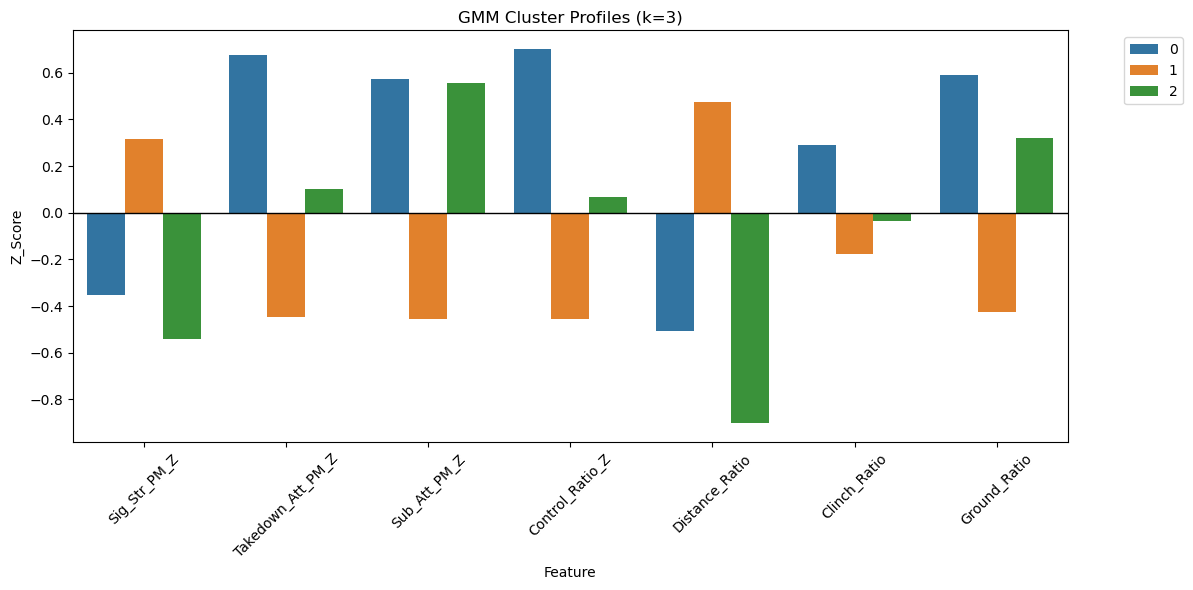

--- Spider plots k=3 ---


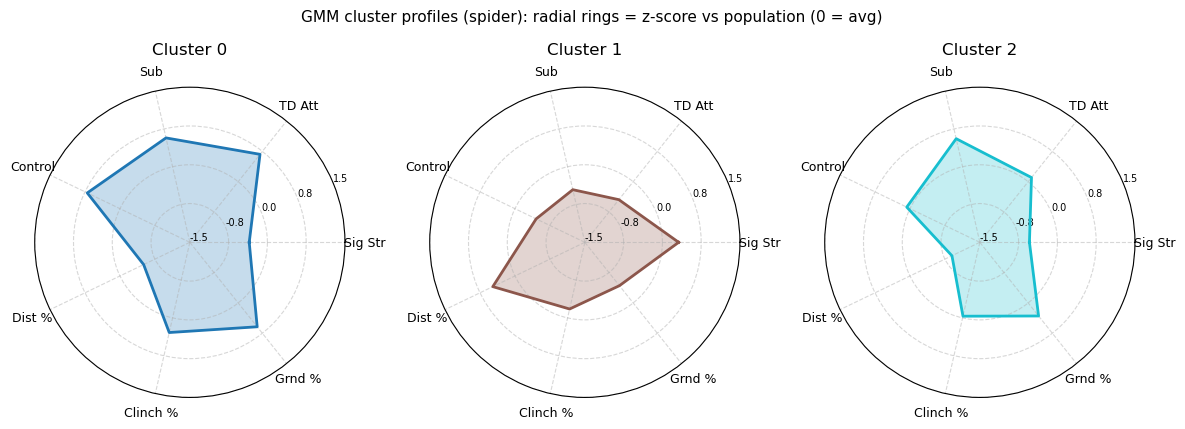

--- Interpreting k=5 (bar charts) ---


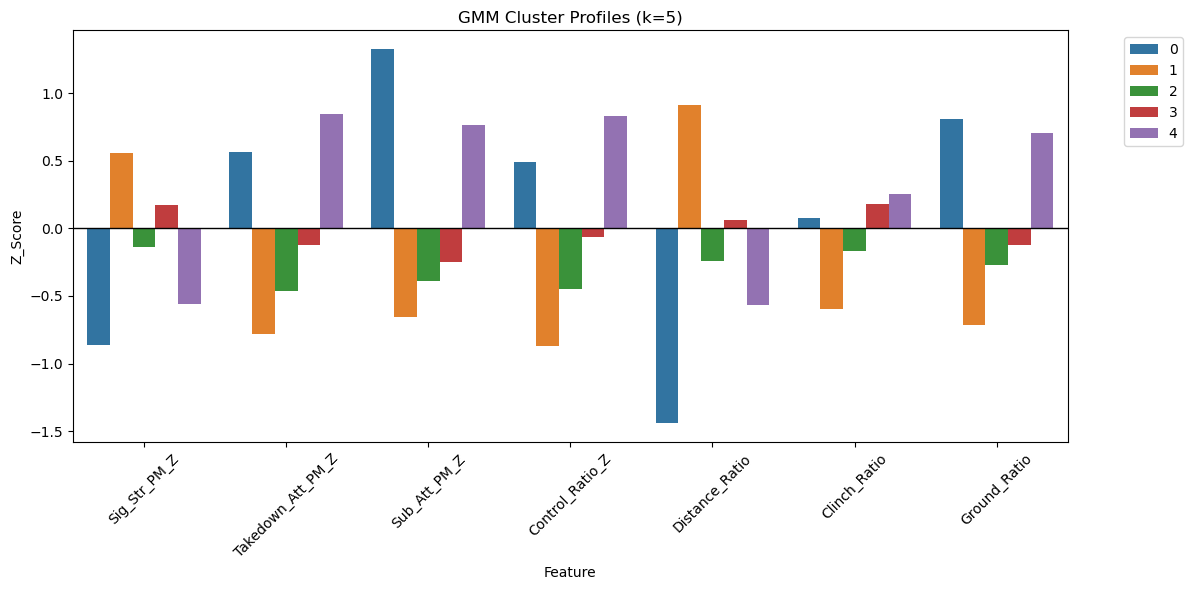

--- Spider plots k=5 ---


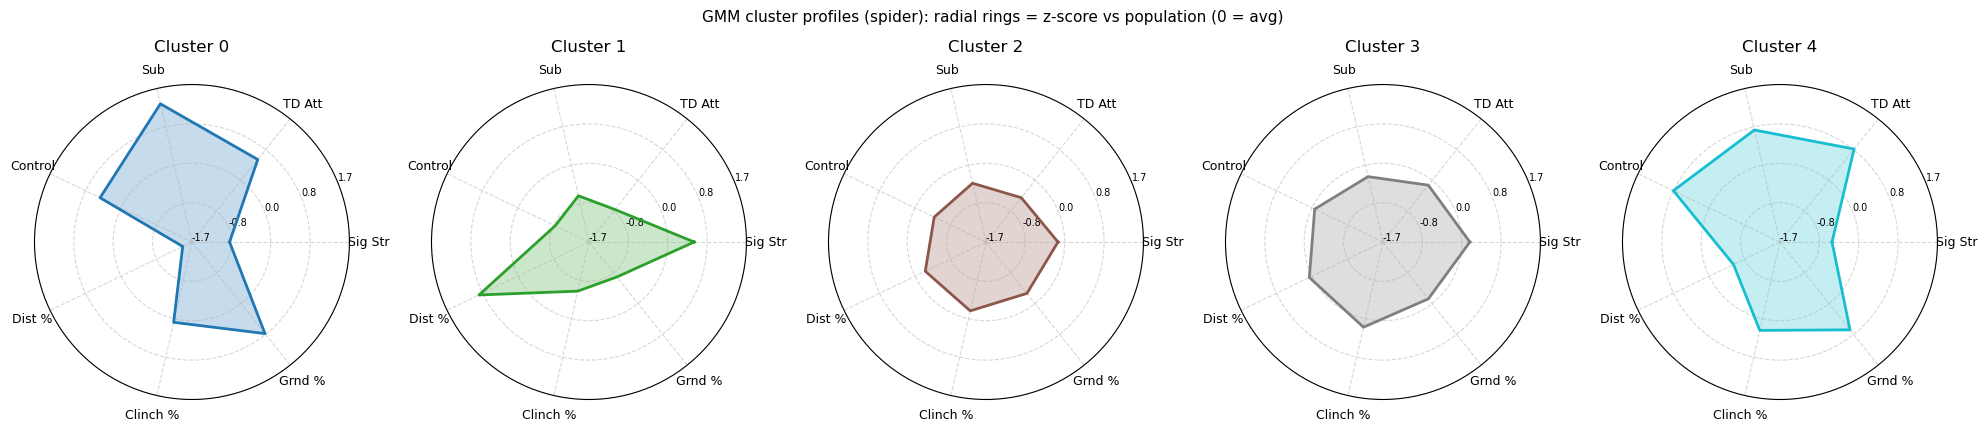

In [3]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 10_gmm_style_discovery.ipynb | code cell index: 5
# Section (from markdown above): Part 2: Centroid Analysis (Interpretability)
# ------------------------------------------------------------------------
# Builds matplotlib/seaborn figures.
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • Follow the code top-to-bottom; prints document shapes and key counts.

def plot_centroids(k, model):
    means = pd.DataFrame(model.means_, columns=features)
    means['Cluster'] = [str(i) for i in range(k)]
    means_melt = means.melt(id_vars='Cluster', var_name='Feature', value_name='Z_Score')
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Feature', y='Z_Score', hue='Cluster', data=means_melt, palette='tab10')
    plt.title(f'GMM Cluster Profiles (k={k})')
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


def plot_cluster_spiders(k, model):
    """Radar (spider) chart: one polygon per cluster. All inputs are z-scaled so magnitudes match."""
    means = model.means_
    B = max(1.5, np.abs(means).max() * 1.15)
    radar_labels = [
        'Sig Str', 'TD Att', 'Sub', 'Control', 'Dist %', 'Clinch %', 'Grnd %'
    ]
    angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False)
    angles_closed = np.concatenate([angles, angles[:1]])

    fig, axes = plt.subplots(1, k, subplot_kw=dict(polar=True), figsize=(4 * k, 4))
    if k == 1:
        axes = [axes]
    cmap = plt.cm.tab10(np.linspace(0, 1, k))

    for i, ax in enumerate(axes):
        z = means[i]
        r = 0.5 + z / (2 * B)
        r_closed = np.concatenate([r, r[:1]])
        ax.plot(angles_closed, r_closed, color=cmap[i], linewidth=2)
        ax.fill(angles_closed, r_closed, color=cmap[i], alpha=0.25)
        ax.set_xticks(angles)
        ax.set_xticklabels(radar_labels, size=9)
        ax.set_ylim(0, 1)
        tick_z = np.linspace(-B, B, 5)
        tick_r = 0.5 + tick_z / (2 * B)
        ax.set_yticks(tick_r)
        ax.set_yticklabels([f'{tz:.1f}' for tz in tick_z], size=7)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_title(f'Cluster {i}', y=1.08)

    fig.suptitle(
        f'GMM cluster profiles (spider): radial rings = z-score vs population (0 = avg)',
        fontsize=11,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


print("--- Interpreting k=3 (bar charts) ---")
plot_centroids(3, models[3])
print("--- Spider plots k=3 ---")
plot_cluster_spiders(3, models[3])

print("--- Interpreting k=5 (bar charts) ---")
plot_centroids(5, models[5])
print("--- Spider plots k=5 ---")
plot_cluster_spiders(5, models[5])


**Interpretation of centroid bar charts:** Each bar is the cluster mean for that feature. Positive Z-scores = above division average; negative = below. E.g. a cluster with high `Sig_Str_PM_Z` and low `Ground_Ratio` is a “striker”; high `Takedown_Att_PM_Z` and `Control_Ratio_Z` = “grappler.” Use these to label clusters.

**Spider (radar) plots:** One chart per cluster. Distance from the center encodes strength on each axis (same z-scaled units as the model; ring labels are approximate z-scores vs the full population). A **bulge** on an axis means that cluster is strong there; a **pull toward center** means near-average or below. Compare shapes across clusters to see who is striker-like vs grappler-like at a glance.

## Part 3: PCA Visualization with Hybridity
We plot the clusters in 2D space. The **transparency (alpha)** of each point represents the model's confidence.

## PCA Component Loadings (mathematical weights)
Run the cell below to see the **loadings table**: each row is a feature, each column is a principal component (PC1, PC2), and each value is the **weight** (loading) — how much that feature contributes to that component.

PCA Component Loadings (weight of each feature per component):
  Rows = features | Columns = PC1, PC2 | Value = loading (contribution)


,PC1,PC2
Sig_Str_PM_Z,-0.279,-0.131
Takedown_Att_PM_Z,0.400,0.296
Sub_Att_PM_Z,0.259,0.332
Control_Ratio_Z,0.470,0.201
Distance_Ratio,-0.470,0.396
Clinch_Ratio,0.223,-0.765
Ground_Ratio,0.451,0.048



Variance explained: PC1=47.3%, PC2=16.9%

Interpretation (fight context):
  PC1: Dominated by ['Distance_Ratio', 'Control_Ratio_Z', 'Ground_Ratio'] — main style axis (e.g. striker vs grappler)
  PC2: Dominated by ['Clinch_Ratio', 'Distance_Ratio', 'Sub_Att_PM_Z'] — secondary axis (e.g. positional preference)
--- Visualizing k=3 ---


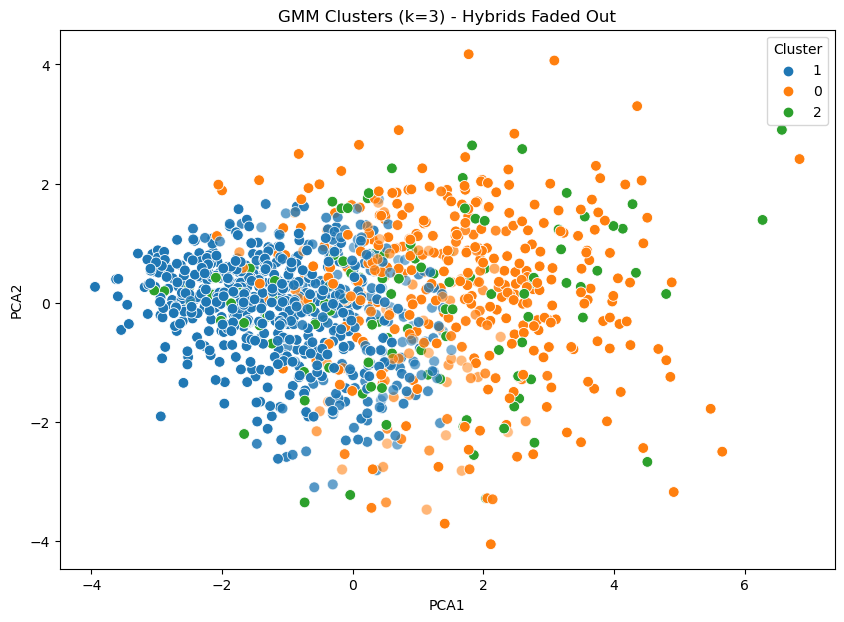

--- Visualizing k=5 ---


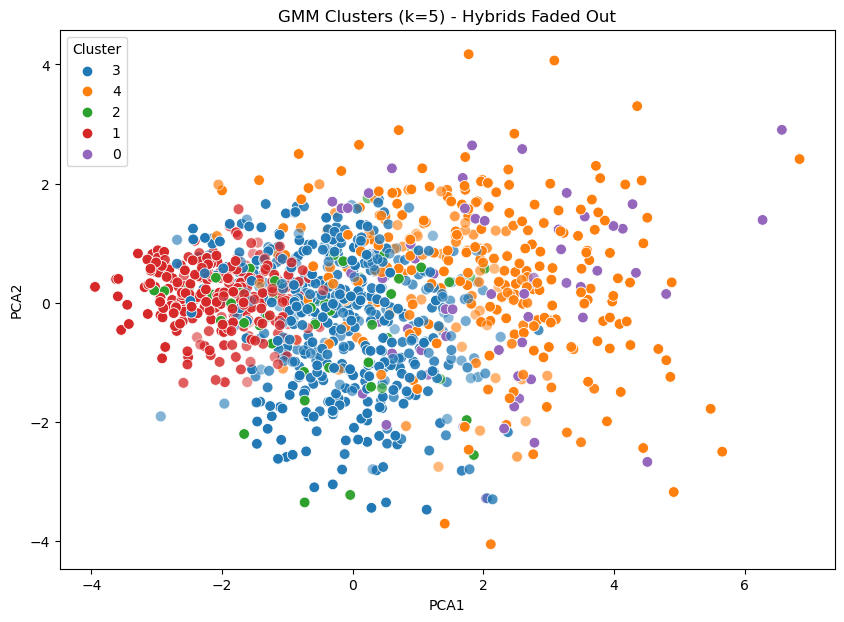

In [4]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 10_gmm_style_discovery.ipynb | code cell index: 9
# Section (from markdown above): PCA Component Loadings (mathematical weights)
# ------------------------------------------------------------------------
# Builds matplotlib/seaborn figures.
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • Follow the code top-to-bottom; prints document shapes and key counts.

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Component loadings: weight of each feature for each PC (rows=features, columns=PCs)
loadings = pd.DataFrame(pca.components_.T, index=features, columns=['PC1', 'PC2'])
print("PCA Component Loadings (weight of each feature per component):")
print("  Rows = features | Columns = PC1, PC2 | Value = loading (contribution)")
try:
    from IPython.display import display
    display(loadings.round(3))
except ImportError:
    print(loadings.round(3).to_string())
print(f"\nVariance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
pc1_top = loadings['PC1'].abs().nlargest(3)
pc2_top = loadings['PC2'].abs().nlargest(3)
print("\nInterpretation (fight context):")
print(f"  PC1: Dominated by {list(pc1_top.index)} — main style axis (e.g. striker vs grappler)")
print(f"  PC2: Dominated by {list(pc2_top.index)} — secondary axis (e.g. positional preference)")

def plot_pca_gmm(k, labels, probs):
    temp_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
    temp_df['Cluster'] = labels.astype(str)
    temp_df['Max_Prob'] = probs.max(axis=1)
    
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        x='PCA1', y='PCA2', 
        hue='Cluster', 
        data=temp_df, 
        palette='tab10', 
        alpha=temp_df['Max_Prob'],
        s=60
    )
    plt.title(f'GMM Clusters (k={k}) - Hybrids Faded Out')
    plt.legend(title='Cluster')
    plt.show()

print("--- Visualizing k=3 ---")
plot_pca_gmm(3, labels[3], probs[3])

print("--- Visualizing k=5 ---")
plot_pca_gmm(5, labels[5], probs[5])


## Part 4: Cluster Examples (Sanity Check)
Let's see who ends up where.

**Interpretation of cluster examples:** Verify that named fighters match their assigned cluster. E.g. known strikers should appear in striker-like clusters; known grapplers in grappler clusters. If not, re-check feature definitions or cluster labels. The Hybrid Score per fighter indicates how “pure” vs. “mixed” their style is.

In [5]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 10_gmm_style_discovery.ipynb | code cell index: 12
# Section (from markdown above): **Interpretation of cluster examples:** Verify that named fighters match their assigned cluster. E.g. known strikers should appear in striker-like clusters; known grapplers in grappler clusters. If no
# ------------------------------------------------------------------------
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • Follow the code top-to-bottom; prints document shapes and key counts.

df_res = df.loc[X.index].copy()

for k in [3, 5]:
    df_res[f'Cluster_k{k}'] = labels[k]
    df_res[f'Hybrid_Score_k{k}'] = entropy(probs[k], axis=1)
    # Persist soft posteriors so downstream notebooks can use them as predictors
    # (notebooks 18-22 consume these as `pk{k}_{i}` columns).
    for i in range(k):
        df_res[f'pk{k}_{i}'] = probs[k][:, i]

    print(f"\n{'='*20}\nExamples for k={k}\n{'='*20}")
    for c in range(k):
        cluster_members = df_res[df_res[f'Cluster_k{k}'] == c]
        pure_examples = cluster_members.sort_values('Total_Fights', ascending=False).head(8)['Fighter'].values
        print(f"Cluster {c} (Most Fights): {pure_examples}")

# Sanity: posteriors should sum to 1 per fighter for each k.
for k in [3, 5]:
    pcols = [f'pk{k}_{i}' for i in range(k)]
    sums = df_res[pcols].sum(axis=1)
    print(f"pk{k} row-sum range: [{sums.min():.4f}, {sums.max():.4f}]")



Examples for k=3
Cluster 0 (Most Fights): ['Jim Miller' 'Clay Guida' 'Diego Sanchez' 'Darren Elkins' 'Nate Diaz'
 'Frank Mir' 'Tito Ortiz' 'Ed Herman']
Cluster 1 (Most Fights): ['Andrei Arlovski' 'Donald Cerrone' 'Rafael Dos Anjos' 'Dustin Poirier'
 'Edson Barboza' 'Michael Johnson' 'Max Holloway' 'Alex Caceres']
Cluster 2 (Most Fights): ['Neil Magny' 'Charles Oliveira' 'Jeremy Stephens' 'Demian Maia'
 'Derrick Lewis' 'Ovince Saint Preux' 'Kevin Holland' 'Gleison Tibau']

Examples for k=5
Cluster 0 (Most Fights): ['Charles Oliveira' 'Demian Maia' 'Joe Lauzon' 'Vitor Belfort'
 'Matt Hughes' 'Josh Koscheck' 'Stefan Struve' 'Thales Leites']
Cluster 1 (Most Fights): ['Andrei Arlovski' 'Edson Barboza' 'Michael Johnson' 'Max Holloway'
 'Michael Bisping' 'King Green' 'Brad Tavares' 'Thiago Alves']
Cluster 2 (Most Fights): ['Neil Magny' 'Jeremy Stephens' 'Derrick Lewis' 'Gleison Tibau'
 'Kevin Holland' 'Ovince Saint Preux' 'Kelvin Gastelum' 'Mauricio Rua']
Cluster 3 (Most Fights): ['Donald Ce

In [6]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 10_gmm_style_discovery.ipynb | code cell index: 13
# Section (from markdown above): **Interpretation of cluster examples:** Verify that named fighters match their assigned cluster. E.g. known strikers should appear in striker-like clusters; known grapplers in grappler clusters. If no
# ------------------------------------------------------------------------
# Persists a DataFrame to CSV under data/processed or similar.
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • Processed outputs are written so downstream notebooks can load them.

# Save Results with both options
df_res.to_csv('../data/processed/ufc_gmm_comparison.csv', index=False)
print("Saved comparison data to ../data/processed/ufc_gmm_comparison.csv")


Saved comparison data to ../data/processed/ufc_gmm_comparison.csv


### Star fighters — GMM k=5 assignment
**Interpretation:** `Hybrid_Score_k5` near 0 → concentrated on one style; higher → more mixed soft assignment.


In [7]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 10_gmm_style_discovery.ipynb | code cell index: 15
# Section (from markdown above): Star fighters — GMM k=5 assignment
# ------------------------------------------------------------------------
# Dependencies: see import statements below.
# Loads one or more CSV files (paths usually relative to notebooks/).
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • CSV reads use paths relative to the notebooks/ working directory.

import pandas as pd
stars = ['Jon Jones', 'Israel Adesanya', 'Khabib Nurmagomedov', 'Conor McGregor', 'Georges St-Pierre', 'Amanda Nunes', 'Anderson Silva', 'Max Holloway', 'Stipe Miocic']
g = pd.read_csv('../data/processed/ufc_gmm_comparison.csv')
cols = [c for c in ['Fighter','Cluster_k5','Hybrid_Score_k5','Total_Fights'] if c in g.columns]
print(g[g['Fighter'].isin(stars)][cols].to_string(index=False))


            Fighter  Cluster_k5  Hybrid_Score_k5  Total_Fights
       Amanda Nunes           4         0.006553            18
     Anderson Silva           3         0.211705            25
     Conor McGregor           1         0.254588            14
  Georges St-Pierre           4         0.666156            22
    Israel Adesanya           1         0.043072            18
          Jon Jones           3         0.285459            24
Khabib Nurmagomedov           4         0.071020            13
       Max Holloway           1         0.030137            31
       Stipe Miocic           3         0.508361            19
